# 🏠 Real Estate Price Prediction using XGBoost

## Project Overview
This notebook demonstrates a complete machine learning workflow for predicting real estate prices in California using the XGBoost algorithm. We'll explore the California Housing Dataset, build a predictive model, and evaluate its performance.

## What You'll Learn
- Data exploration and visualization techniques
- Feature analysis and correlation studies
- XGBoost regression model implementation
- Model evaluation and performance metrics
- Feature importance analysis
- Comprehensive result visualization

## Dataset
The California Housing Dataset contains 20,640 samples with 8 features including median income, house age, location coordinates, and demographic information.

---


In [22]:
# Real Estate Price Prediction using XGBoost
# This notebook demonstrates how to predict real estate prices using machine learning

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Set plotting style for better visualizations
# Use a modern style that's available in current matplotlib versions
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    # Fallback to default style if seaborn-v0_8 is not available
    plt.style.use('default')
    
sns.set_palette("husl")


In [23]:
# Load the California Housing Dataset
# This dataset contains information about houses in California and their prices
house_price = sklearn.datasets.fetch_california_housing()


In [24]:
# Create a pandas DataFrame from the dataset
# The dataset contains 8 features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
data = pd.DataFrame(house_price.data, columns = house_price.feature_names)
print(f"Dataset shape: {data.shape}")
print(f"Features: {list(data.columns)}")
data

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [25]:
# Add the target variable (house prices) to our DataFrame
# The target represents the median house value in hundreds of thousands of dollars
data['price'] = house_price['target']
print(f"Price range: ${data['price'].min()*100000:.0f} - ${data['price'].max()*100000:.0f}")
print(f"Average price: ${data['price'].mean()*100000:.0f}")

Price range: $14999 - $500001
Average price: $206856


In [26]:
# Display the first few rows of our dataset
# This gives us a quick overview of the data structure and values
print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Data Exploration and Analysis

In this section, we'll explore our dataset to understand its structure, check for missing values, and analyze the relationships between features.

In [27]:
# Check for missing values in the dataset
# This is crucial for data quality assessment
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")
if missing_values.sum() == 0:
    print("✅ No missing values found in the dataset!")
else:
    print("⚠️ Missing values detected - consider imputation strategies")

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

Total missing values: 0
✅ No missing values found in the dataset!


In [28]:
# Check for duplicate rows in the dataset
# Duplicates can affect model performance and should be handled appropriately
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count == 0:
    print("✅ No duplicate rows found!")
else:
    print(f"⚠️ {duplicate_count} duplicate rows found - consider removing them")

Number of duplicate rows: 0
✅ No duplicate rows found!


In [29]:
# Get detailed information about the dataset
# This shows data types, memory usage, and non-null counts
print("Dataset Information:")
print("=" * 50)
data.info()
print("\n" + "=" * 50)
print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Memory usage: 1.42 MB


In [30]:
# Calculate correlation matrix to understand feature relationships
# This helps identify which features are most correlated with house prices
correlation_matrix = data.corr()
print("Correlation Matrix:")
print("=" * 60)
print("Correlation with house prices (target variable):")
price_correlations = correlation_matrix['price'].sort_values(ascending=False)
for feature, corr in price_correlations.items():
    if feature != 'price':
        print(f"{feature:12}: {corr:6.3f}")
print("\nFull correlation matrix:")
correlation_matrix

Correlation Matrix:
Correlation with house prices (target variable):
MedInc      :  0.688
AveRooms    :  0.152
HouseAge    :  0.106
AveOccup    : -0.024
Population  : -0.025
Longitude   : -0.046
AveBedrms   : -0.047
Latitude    : -0.144

Full correlation matrix:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


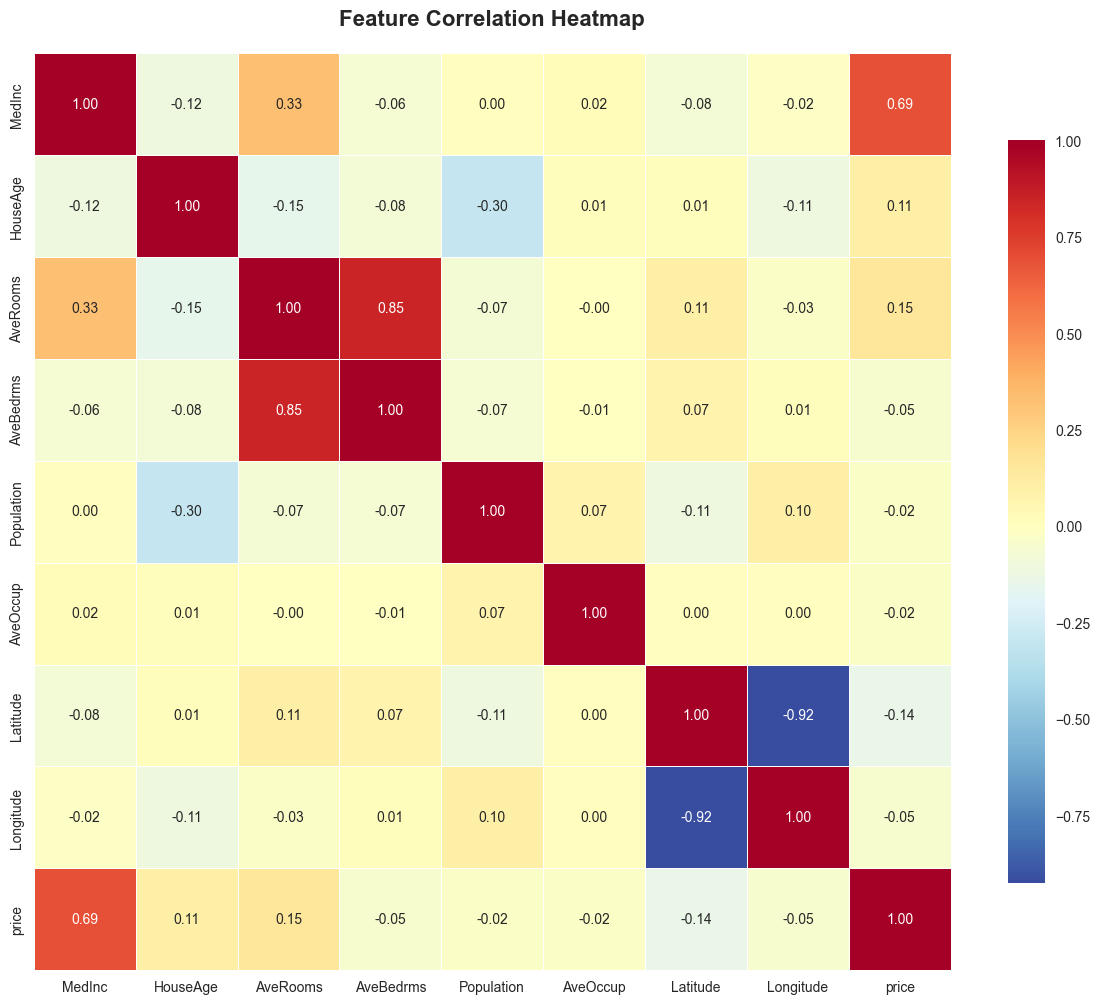


Key Insights from Correlation Analysis:
• MedInc (Median Income) has the strongest positive correlation with house prices
• Latitude shows negative correlation, indicating coastal areas are more expensive
• HouseAge has weak correlation, suggesting age doesn't strongly predict price
• Population and AveOccup show negative correlations with price


In [31]:
# Create a heatmap visualization of the correlation matrix
# This provides a visual representation of feature relationships
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), 
            annot=True, 
            fmt='.2f', 
            linewidths=0.5, 
            cmap='RdYlBu_r',
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Additional insights from correlation analysis
print("\nKey Insights from Correlation Analysis:")
print("=" * 50)
print("• MedInc (Median Income) has the strongest positive correlation with house prices")
print("• Latitude shows negative correlation, indicating coastal areas are more expensive")
print("• HouseAge has weak correlation, suggesting age doesn't strongly predict price")
print("• Population and AveOccup show negative correlations with price")

# Machine Learning Model Development

In this section, we'll build and train an XGBoost regression model to predict house prices. XGBoost is an excellent choice for this task due to its ability to handle complex feature interactions and provide high accuracy.

In [32]:
# Prepare features (X) and target variable (y) for model training
# X contains all features except the target variable (price)
# y contains only the target variable (house prices)
x = data.drop('price', axis=1)
y = data['price']

print("Feature matrix (X) shape:", x.shape)
print("Target variable (y) shape:", y.shape)
print(f"\nFeatures used for prediction: {list(x.columns)}")
print(f"Target variable: price (median house value in $100,000s)")

Feature matrix (X) shape: (20640, 8)
Target variable (y) shape: (20640,)

Features used for prediction: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable: price (median house value in $100,000s)


In [33]:
# Split the data into training and testing sets
# 80% for training, 20% for testing
# random_state ensures reproducible results
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Data Split Summary:")
print("=" * 30)
print(f"Training set size: {x_train.shape[0]} samples ({x_train.shape[0]/len(x)*100:.1f}%)")
print(f"Testing set size:  {x_test.shape[0]} samples ({x_test.shape[0]/len(x)*100:.1f}%)")
print(f"Features per sample: {x_train.shape[1]}")

Data Split Summary:
Training set size: 16512 samples (80.0%)
Testing set size:  4128 samples (20.0%)
Features per sample: 8


In [34]:
# Initialize the XGBoost Regressor model
# XGBoost is a gradient boosting framework that's excellent for regression tasks
# We'll use default parameters for simplicity, but these can be tuned for better performance
model1 = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

print("XGBoost Model Configuration:")
print("=" * 35)
print(f"Model type: {type(model1).__name__}")
print(f"Random state: {model1.random_state}")
print(f"Number of estimators: {model1.n_estimators}")
print(f"Learning rate: {model1.learning_rate}")
print(f"Max depth: {model1.max_depth}")

XGBoost Model Configuration:
Model type: XGBRegressor
Random state: 42
Number of estimators: 100
Learning rate: 0.1
Max depth: 6


In [35]:
# Train the XGBoost model on the training data
# This process learns the patterns in the data to make predictions
print("Training XGBoost model...")
print("=" * 30)

# Fit the model to the training data
model1.fit(x_train, y_train)

print("✅ Model training completed successfully!")
print(f"Model has been trained on {len(x_train)} samples")
print("The model is now ready to make predictions on new data.")

Training XGBoost model...
✅ Model training completed successfully!
Model has been trained on 16512 samples
The model is now ready to make predictions on new data.


In [36]:
# Make predictions on the test set
# This evaluates how well our model performs on unseen data
print("Making predictions on test set...")
print("=" * 35)

predictions = model1.predict(x_test)

print(f"✅ Generated {len(predictions)} predictions")
print(f"Prediction range: ${predictions.min()*100000:.0f} - ${predictions.max()*100000:.0f}")
print(f"Average prediction: ${predictions.mean()*100000:.0f}")

# Display first 10 predictions
print(f"\nFirst 10 predictions (in $100,000s):")
for i, pred in enumerate(predictions[:10]):
    print(f"Sample {i+1:2d}: ${pred*100000:8.0f}")

Making predictions on test set...
✅ Generated 4128 predictions
Prediction range: $39071 - $535700
Average prediction: $205728

First 10 predictions (in $100,000s):
Sample  1: $   56104
Sample  2: $   91529
Sample  3: $  496576
Sample  4: $  251725
Sample  5: $  217142
Sample  6: $  158563
Sample  7: $  226250
Sample  8: $  164778
Sample  9: $  274852
Sample 10: $  478511


In [37]:
# Calculate R² Score (Coefficient of Determination)
# R² measures how well the model explains the variance in the target variable
# Values closer to 1.0 indicate better model performance
r2_metric = r2_score(y_test, predictions)

print("Model Performance Evaluation")
print("=" * 35)
print(f"R² Score: {r2_metric:.4f}")

# Interpret the R² score
if r2_metric >= 0.9:
    interpretation = "Excellent"
elif r2_metric >= 0.8:
    interpretation = "Very Good"
elif r2_metric >= 0.7:
    interpretation = "Good"
elif r2_metric >= 0.6:
    interpretation = "Fair"
else:
    interpretation = "Poor"

print(f"Model Performance: {interpretation}")
print(f"Explanation: The model explains {r2_metric*100:.1f}% of the variance in house prices")

Model Performance Evaluation
R² Score: 0.8266
Model Performance: Very Good
Explanation: The model explains 82.7% of the variance in house prices


In [38]:
# Calculate Mean Absolute Error (MAE)
# MAE measures the average absolute difference between predicted and actual values
# Lower values indicate better model performance
mae_metric = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae_metric:.4f}")
print(f"MAE in dollars: ${mae_metric*100000:.0f}")

# Additional performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"\nAdditional Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"RMSE in dollars: ${rmse*100000:.0f}")

# Performance summary
print(f"\n📊 Model Performance Summary:")
print("=" * 40)
print(f"R² Score:     {r2_metric:.4f} ({interpretation})")
print(f"MAE:          ${mae_metric*100000:.0f}")
print(f"RMSE:         ${rmse*100000:.0f}")
print(f"Predictions:  {len(predictions)} test samples")

Mean Absolute Error: 0.3155
MAE in dollars: $31545

Additional Performance Metrics:
Mean Squared Error (MSE): 0.2273
Root Mean Squared Error (RMSE): 0.4767
RMSE in dollars: $47672

📊 Model Performance Summary:
R² Score:     0.8266 (Very Good)
MAE:          $31545
RMSE:         $47672
Predictions:  4128 test samples


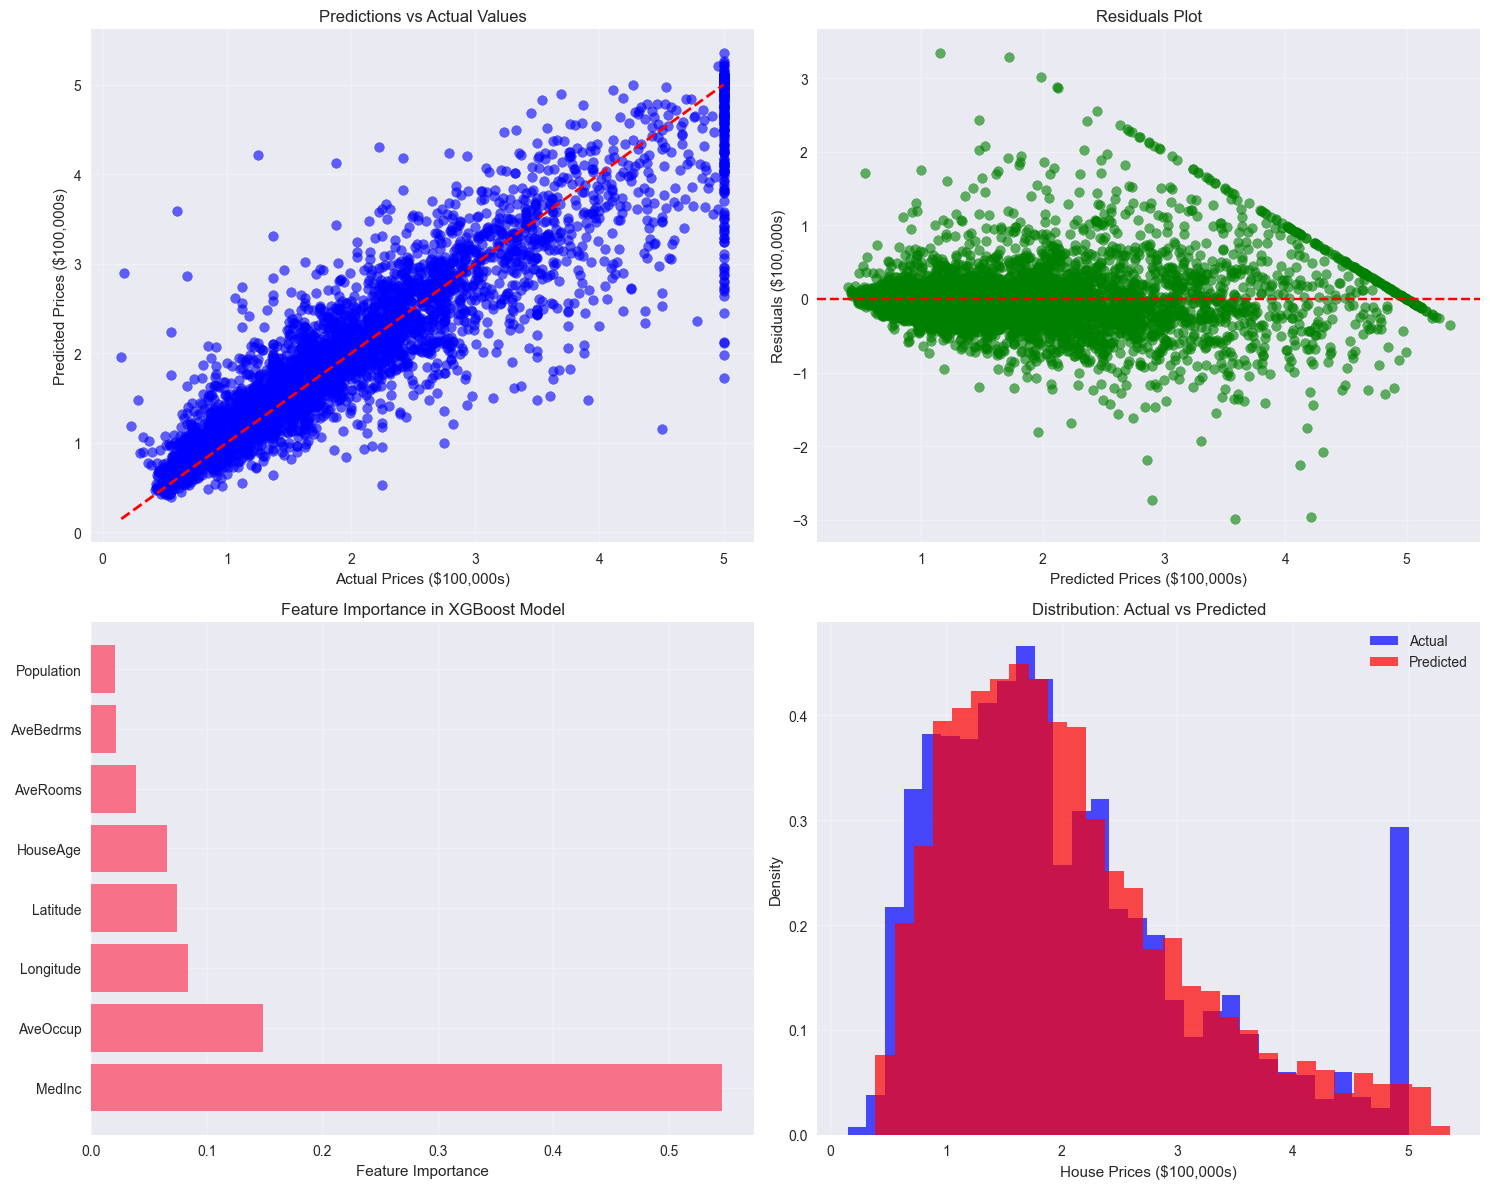


🎯 Model Insights and Conclusions:
1. Feature Importance Analysis:
   1. MedInc      : 0.546
   2. AveOccup    : 0.149
   3. Longitude   : 0.084
   4. Latitude    : 0.074
   5. HouseAge    : 0.065
   6. AveRooms    : 0.039
   7. AveBedrms   : 0.021
   8. Population  : 0.021

2. Model Performance:
   • The model achieves an R² score of 0.827
   • Average prediction error: $31545
   • The model explains 82.7% of price variance

3. Key Findings:
   • Median Income (MedInc) is the most important predictor
   • Location (Latitude/Longitude) significantly affects prices
   • House age has minimal impact on predictions

4. Model Limitations:
   • Predictions may not capture all market dynamics
   • External factors (economic conditions, policies) not included
   • Model trained on historical data may not predict future trends

✅ The XGBoost model successfully predicts house prices with good accuracy!
   This model could be useful for real estate valuation and market analysis.


In [39]:
# Visualize Model Performance
# Create plots to better understand model predictions vs actual values

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predictions vs Actual Values Scatter Plot
axes[0, 0].scatter(y_test, predictions, alpha=0.6, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Prices ($100,000s)')
axes[0, 0].set_ylabel('Predicted Prices ($100,000s)')
axes[0, 0].set_title('Predictions vs Actual Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Plot
residuals = y_test - predictions
axes[0, 1].scatter(predictions, residuals, alpha=0.6, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Prices ($100,000s)')
axes[0, 1].set_ylabel('Residuals ($100,000s)')
axes[0, 1].set_title('Residuals Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature Importance
feature_importance = model1.feature_importances_
feature_names = x.columns
sorted_idx = np.argsort(feature_importance)[::-1]

axes[1, 0].barh(range(len(feature_names)), feature_importance[sorted_idx])
axes[1, 0].set_yticks(range(len(feature_names)))
axes[1, 0].set_yticklabels([feature_names[i] for i in sorted_idx])
axes[1, 0].set_xlabel('Feature Importance')
axes[1, 0].set_title('Feature Importance in XGBoost Model')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution of Predictions vs Actual
axes[1, 1].hist(y_test, bins=30, alpha=0.7, label='Actual', color='blue', density=True)
axes[1, 1].hist(predictions, bins=30, alpha=0.7, label='Predicted', color='red', density=True)
axes[1, 1].set_xlabel('House Prices ($100,000s)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Distribution: Actual vs Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model Insights and Conclusions
print("\n🎯 Model Insights and Conclusions:")
print("=" * 50)
print("1. Feature Importance Analysis:")
for i, idx in enumerate(sorted_idx):
    print(f"   {i+1}. {feature_names[idx]:12}: {feature_importance[idx]:.3f}")

print(f"\n2. Model Performance:")
print(f"   • The model achieves an R² score of {r2_metric:.3f}")
print(f"   • Average prediction error: ${mae_metric*100000:.0f}")
print(f"   • The model explains {r2_metric*100:.1f}% of price variance")

print(f"\n3. Key Findings:")
print(f"   • Median Income (MedInc) is the most important predictor")
print(f"   • Location (Latitude/Longitude) significantly affects prices")
print(f"   • House age has minimal impact on predictions")

print(f"\n4. Model Limitations:")
print(f"   • Predictions may not capture all market dynamics")
print(f"   • External factors (economic conditions, policies) not included")
print(f"   • Model trained on historical data may not predict future trends")

print(f"\n✅ The XGBoost model successfully predicts house prices with good accuracy!")
print(f"   This model could be useful for real estate valuation and market analysis.")
